#  E-Commerce Sales Analysis

##  Project Overview

This project analyzes an e-commerce sales dataset to identify
sales trends, profitable products, customer behavior, and
regional performance.

###  Objectives

- Analyze overall sales and profit
- Identify top-performing products
- Analyze sales by category and region
- Study monthly sales trends
- Understand the relationship between sales and profit
- Generate useful business insights

###  Tools & Libraries

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Jupyter Notebook

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


**`Step 2 —E-Commerce Dataset Create`**

In [2]:
import pandas as pd
import numpy as np

np.random.seed(42)

n = 500

products = [
    "Laptop", "Smartphone", "Headphones", "Keyboard",
    "Mouse", "Monitor", "Tablet", "Smartwatch",
    "Printer", "Camera"
]

categories = {
    "Laptop": "Electronics",
    "Smartphone": "Electronics",
    "Headphones": "Accessories",
    "Keyboard": "Accessories",
    "Mouse": "Accessories",
    "Monitor": "Electronics",
    "Tablet": "Electronics",
    "Smartwatch": "Wearables",
    "Printer": "Electronics",
    "Camera": "Electronics"
}

regions = ["North", "South", "East", "West"]
payment_methods = ["Credit Card", "Debit Card", "UPI", "Cash on Delivery"]

df = pd.DataFrame({
    "Order_ID": range(1001, 1001 + n),
    "Customer_ID": np.random.randint(101, 201, n),
    "Product": np.random.choice(products, n),
    "Region": np.random.choice(regions, n),
    "Payment_Method": np.random.choice(payment_methods, n),
    "Quantity": np.random.randint(1, 6, n),
    "Unit_Price": np.random.choice(
        [500, 1000, 1500, 2500, 5000, 10000, 25000, 50000], n
    )
})

df["Category"] = df["Product"].map(categories)

df["Sales"] = df["Quantity"] * df["Unit_Price"]

df["Profit"] = (df["Sales"] * np.random.uniform(0.08, 0.30, n)).round(2)

df.head()

,Order_ID,Customer_ID,Product,Region,Payment_Method,Quantity,Unit_Price,Category,Sales,Profit
0,1001,152,Camera,South,Cash on Delivery,4,5000,Electronics,20000,3998.12
1,1002,193,Headphones,West,Debit Card,4,1000,Accessories,4000,1186.51
2,1003,115,Mouse,East,Debit Card,5,1500,Accessories,7500,2146.69
3,1004,172,Monitor,East,Credit Card,5,10000,Electronics,50000,4474.91
4,1005,161,Printer,North,Cash on Delivery,5,10000,Electronics,50000,5812.96


**`Step 3 — Dataset Inspection`**

In [8]:
# Dataset  size
df.shape


(500, 10)

In [9]:
# Data types and information
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Order_ID        500 non-null    int64  
 1   Customer_ID     500 non-null    int32  
 2   Product         500 non-null    str    
 3   Region          500 non-null    str    
 4   Payment_Method  500 non-null    str    
 5   Quantity        500 non-null    int32  
 6   Unit_Price      500 non-null    int64  
 7   Category        500 non-null    str    
 8   Sales           500 non-null    int64  
 9   Profit          500 non-null    float64
dtypes: float64(1), int32(2), int64(3), str(4)
memory usage: 51.2 KB


In [10]:
# Missing values

df.isnull().sum()

Order_ID          0
Customer_ID       0
Product           0
Region            0
Payment_Method    0
Quantity          0
Unit_Price        0
Category          0
Sales             0
Profit            0
dtype: int64

In [11]:
# Duplicate orders

df.duplicated().sum()


np.int64(0)

In [12]:
# Statistical Summary

df.describe()

,Order_ID,Customer_ID,Quantity,Unit_Price,Sales,Profit
count,500.000000,500.00000,500.000000,500.000000,500.000000,500.000000
mean,1250.500000,149.87400,3.002000,12330.000000,38875.000000,7136.682520
std,144.481833,29.56983,1.431816,16586.721758,60439.629156,11628.988009
min,1001.000000,101.00000,1.000000,500.000000,500.000000,45.750000
25%,1125.750000,124.00000,2.000000,1500.000000,3000.000000,557.215000
50%,1250.500000,151.00000,3.000000,5000.000000,10000.000000,1952.165000
75%,1375.250000,173.25000,4.000000,25000.000000,50000.000000,8403.050000
max,1500.000000,200.00000,5.000000,50000.000000,250000.000000,68215.790000


**`Step 4 — Business KPIs`**

In [13]:
# Total Sales

total_sales = df["Sales"].sum()

print("Total Sales:", total_sales)

Total Sales: 19437500


In [14]:
# Total Profit

total_profit = df["Profit"].sum()

print("Total Profit:", total_profit)

Total Profit: 3568341.2600000007


In [15]:
# Total Orders

total_orders = df["Order_ID"].nunique()

print("Total Orders:", total_orders)

Total Orders: 500


In [16]:
# Average Order Value

average_order_value = df["Sales"].mean()

print("Average Order Value:", round(average_order_value, 2))

Average Order Value: 38875.0


**`Step 5 — Product Performance Analysis`**

In [17]:
# Product-wise Sales

product_sales = df.groupby("Product")["Sales"].sum().sort_values(ascending=False)

print(product_sales)

Product
Camera        3185500
Headphones    2233500
Smartwatch    2114500
Printer       2103500
Laptop        1857500
Monitor       1789000
Smartphone    1780000
Mouse         1550500
Tablet        1488000
Keyboard      1335500
Name: Sales, dtype: int64


In [18]:
# Product-wise Profit

product_profit = df.groupby("Product")["Profit"].sum().sort_values(ascending=False)

print(product_profit)


Product
Camera        601506.92
Smartwatch    426721.17
Headphones    412538.95
Printer       363597.70
Monitor       343436.08
Laptop        319984.41
Smartphone    291890.09
Mouse         281915.68
Tablet        275748.80
Keyboard      251001.46
Name: Profit, dtype: float64


In [19]:
# Top 5 Products by Sales

top_5_products = product_sales.head(5)

print(top_5_products)

Product
Camera        3185500
Headphones    2233500
Smartwatch    2114500
Printer       2103500
Laptop        1857500
Name: Sales, dtype: int64


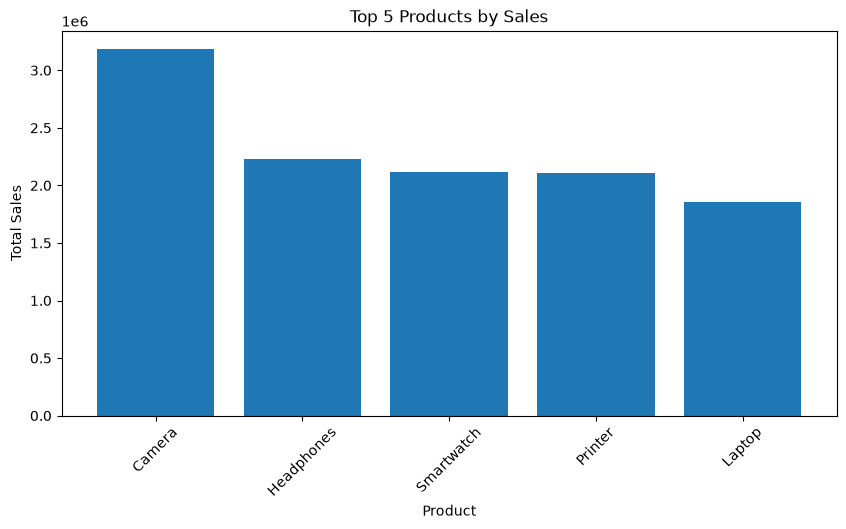

In [22]:
# Top 5 Products ka Graph

plt.figure(figsize=(10, 5))

plt.bar(top_5_products.index, top_5_products.values)

plt.xlabel("Product")
plt.ylabel("Total Sales")
plt.title("Top 5 Products by Sales")

plt.xticks(rotation=45)
plt.show()

**`Step 6 — Category-wise Analysis`**

In [23]:
# Category-wise Sales

category_sales = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)

print(category_sales)

Category
Electronics    12203500
Accessories     5119500
Wearables       2114500
Name: Sales, dtype: int64


In [24]:
# Category-wise Profit

category_profit = df.groupby("Category")["Profit"].sum().sort_values(ascending=False)

print(category_profit)

Category
Electronics    2196164.00
Accessories     945456.09
Wearables       426721.17
Name: Profit, dtype: float64


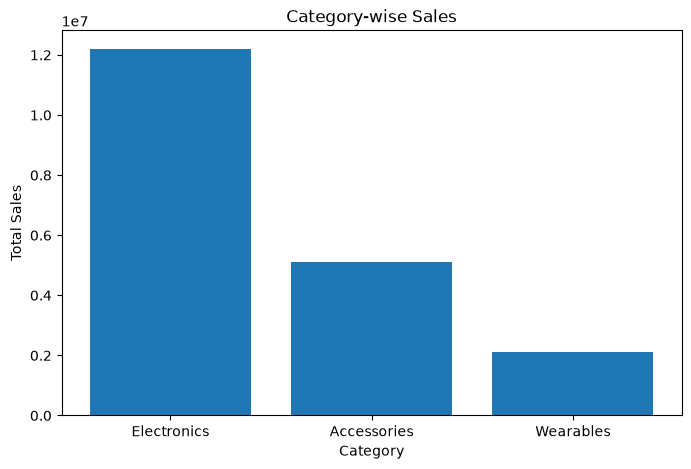

In [25]:
# Category Sales Graph

plt.figure(figsize=(8, 5))

plt.bar(category_sales.index, category_sales.values)

plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.title("Category-wise Sales")

plt.show()


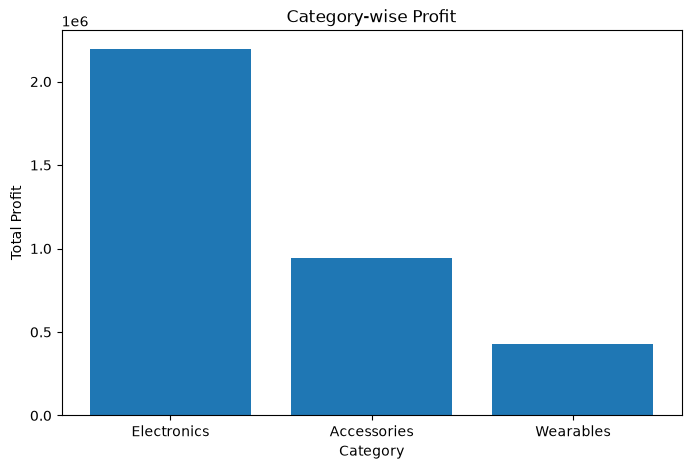

In [26]:
# Category Profit Graph

plt.figure(figsize=(8, 5))

plt.bar(category_profit.index, category_profit.values)

plt.xlabel("Category")
plt.ylabel("Total Profit")
plt.title("Category-wise Profit")

plt.show()

**`Step 7: Regional Analysis`**

In [27]:
# Region-wise Sales

region_sales = df.groupby("Region")["Sales"].sum().sort_values(ascending=False)

print(region_sales)

Region
East     5713000
South    4663500
North    4587500
West     4473500
Name: Sales, dtype: int64


In [28]:
# Region-wise Profit

region_profit = df.groupby("Region")["Profit"].sum().sort_values(ascending=False)

print(region_profit)

Region
East     1010828.01
South     860596.79
West      858431.44
North     838485.02
Name: Profit, dtype: float64


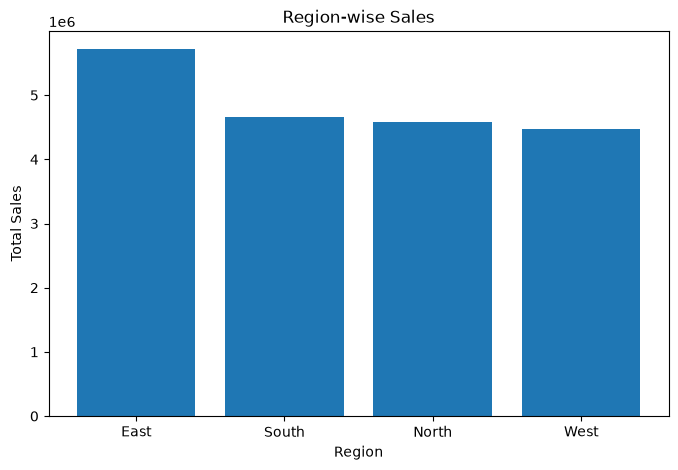

In [29]:
# Region Sales Graph

plt.figure(figsize=(8, 5))

plt.bar(region_sales.index, region_sales.values)

plt.xlabel("Region")
plt.ylabel("Total Sales")
plt.title("Region-wise Sales")

plt.show()

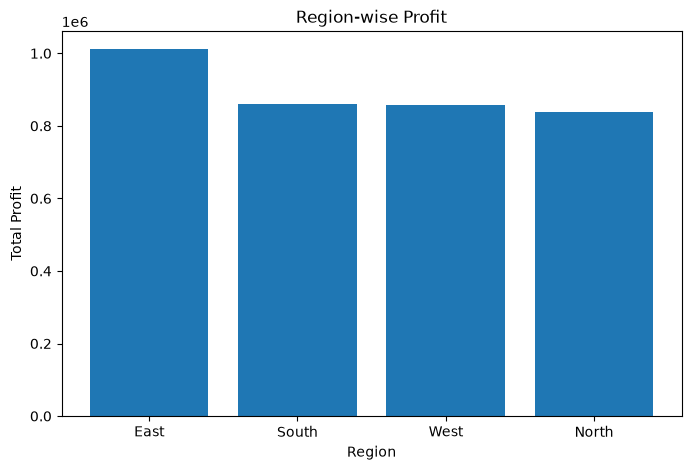

In [30]:
# Region Profit Graph

plt.figure(figsize=(8, 5))

plt.bar(region_profit.index, region_profit.values)

plt.xlabel("Region")
plt.ylabel("Total Profit")
plt.title("Region-wise Profit")

plt.show()

**`Step 8 — Payment Method Analysis`**

In [31]:
# Payment Method Orders

payment_orders = df["Payment_Method"].value_counts()

print(payment_orders)

Payment_Method
Credit Card         136
UPI                 130
Debit Card          122
Cash on Delivery    112
Name: count, dtype: int64


In [32]:
# Payment Method Sales

payment_sales = df.groupby("Payment_Method")["Sales"].sum().sort_values(ascending=False)

print(payment_sales)

Payment_Method
Credit Card         6139000
Cash on Delivery    4711000
Debit Card          4400500
UPI                 4187000
Name: Sales, dtype: int64


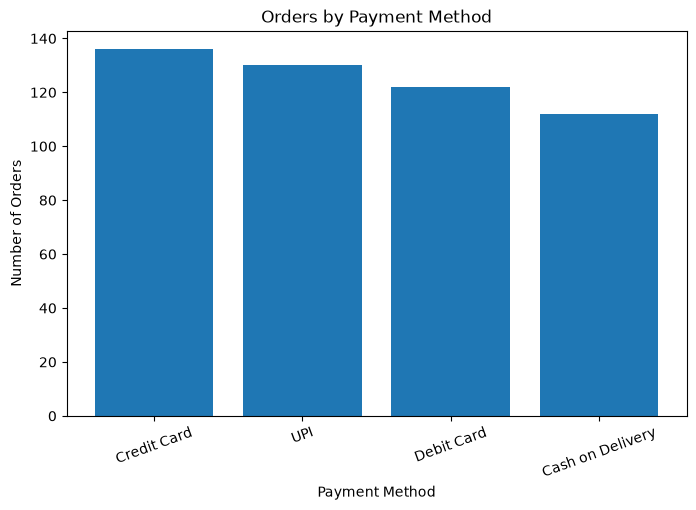

In [33]:
# Orders  Graph

plt.figure(figsize=(8, 5))

plt.bar(payment_orders.index, payment_orders.values)

plt.xlabel("Payment Method")
plt.ylabel("Number of Orders")
plt.title("Orders by Payment Method")

plt.xticks(rotation=20)
plt.show()

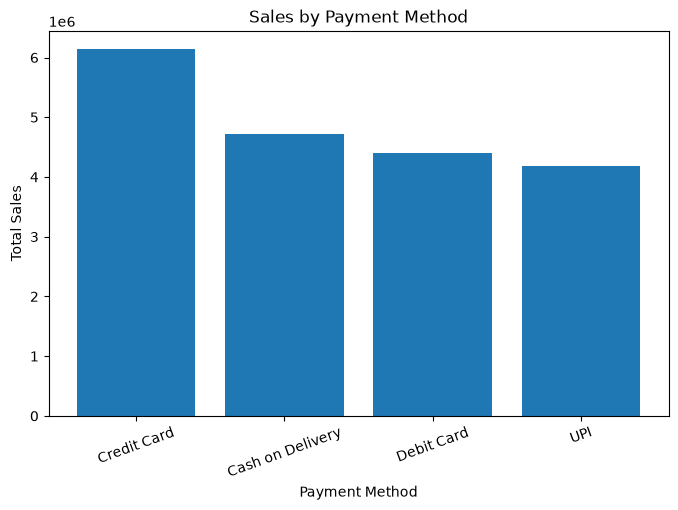

In [34]:
# Sales  Graph

plt.figure(figsize=(8, 5))

plt.bar(payment_sales.index, payment_sales.values)

plt.xlabel("Payment Method")
plt.ylabel("Total Sales")
plt.title("Sales by Payment Method")

plt.xticks(rotation=20)
plt.show()

**`Step 9 — Customer Analysis`**

In [35]:
# Customer-wise Sales

customer_sales = (
    df.groupby("Customer_ID")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

print(customer_sales.head(10))

Customer_ID
189    911500
199    755500
102    663000
190    651000
132    630000
116    487500
147    482500
160    434000
167    417500
108    416000
Name: Sales, dtype: int64


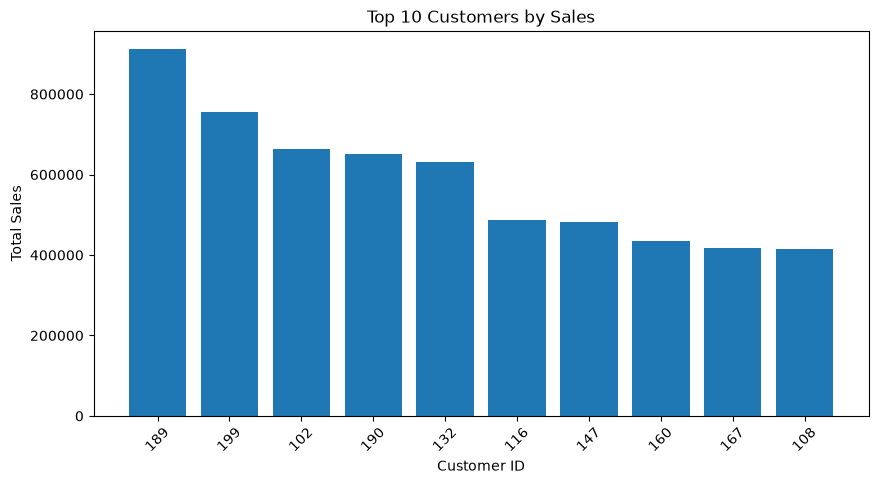

In [36]:
# Top 10 Customers Graph

top_10_customers = customer_sales.head(10)

plt.figure(figsize=(10, 5))

plt.bar(
    top_10_customers.index.astype(str),
    top_10_customers.values
)

plt.xlabel("Customer ID")
plt.ylabel("Total Sales")
plt.title("Top 10 Customers by Sales")

plt.xticks(rotation=45)
plt.show()

In [37]:
# Orders per Customer

customer_orders = (
    df.groupby("Customer_ID")["Order_ID"]
    .nunique()
    .sort_values(ascending=False)
)

print(customer_orders.head(10))

Customer_ID
162    14
133    10
102    10
199    10
190    10
160    10
148     9
124     9
101     9
132     8
Name: Order_ID, dtype: int64


**`Step 10 — Sales vs Profit Analysis`**

In [38]:
# Correlation
sales_profit_corr = df["Sales"].corr(df["Profit"])

print("Sales-Profit Correlation:", round(sales_profit_corr, 3))

Sales-Profit Correlation: 0.931


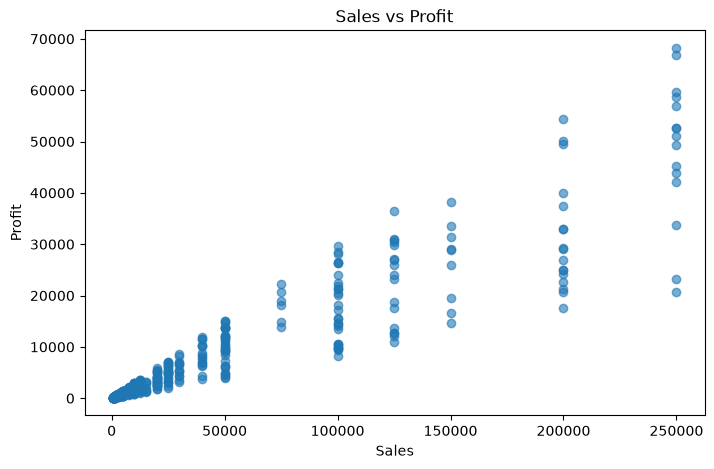

In [39]:
# Scatter Plot

plt.figure(figsize=(8, 5))

plt.scatter(df["Sales"], df["Profit"], alpha=0.6)

plt.xlabel("Sales")
plt.ylabel("Profit")
plt.title("Sales vs Profit")

plt.show()

In [40]:
# Profit Margin

df["Profit_Margin"] = (df["Profit"] / df["Sales"]) * 100

print("Average Profit Margin:", round(df["Profit_Margin"].mean(), 2), "%")

Average Profit Margin: 18.94 %


**`Step 11 — Sales Trend Analysis`**

In [41]:
# Order Date Create

date_range = pd.date_range(
    start="2025-01-01",
    end="2025-12-31",
    periods=len(df)
)

df["Order_Date"] = date_range

df.head()

,Order_ID,Customer_ID,Product,Region,Payment_Method,Quantity,Unit_Price,Category,Sales,Profit,Profit_Margin,Order_Date
0,1001,152,Camera,South,Cash on Delivery,4,5000,Electronics,20000,3998.12,19.990600,2025-01-01 00:00:00.000000
1,1002,193,Headphones,West,Debit Card,4,1000,Accessories,4000,1186.51,29.662750,2025-01-01 17:30:25.250501
2,1003,115,Mouse,East,Debit Card,5,1500,Accessories,7500,2146.69,28.622533,2025-01-02 11:00:50.501002
3,1004,172,Monitor,East,Credit Card,5,10000,Electronics,50000,4474.91,8.949820,2025-01-03 04:31:15.751503
4,1005,161,Printer,North,Cash on Delivery,5,10000,Electronics,50000,5812.96,11.625920,2025-01-03 22:01:41.002004


In [42]:
# Monthly Sales

monthly_sales = (
    df.groupby(df["Order_Date"].dt.month)["Sales"]
    .sum()
)

print(monthly_sales)

Order_Date
1     2149500
2     1323500
3      998500
4     1214500
5     1609000
6     1624000
7     1074500
8     1107500
9     2133000
10    2474000
11    1652000
12    2077500
Name: Sales, dtype: int64


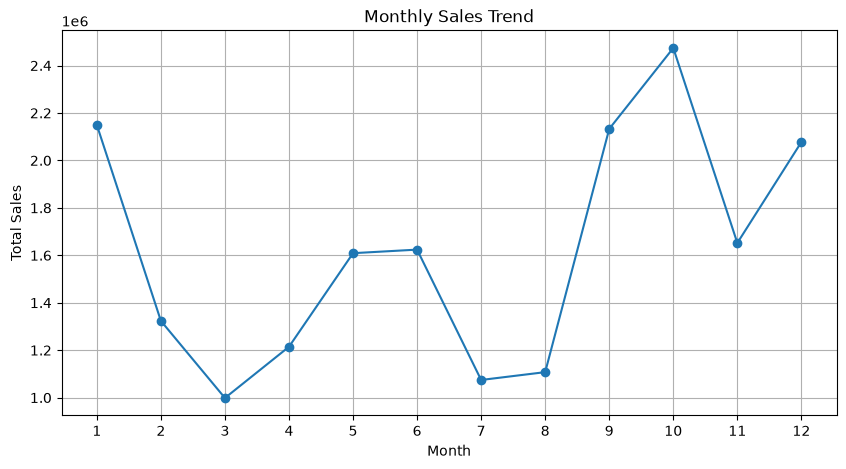

In [43]:
# Monthly Sales Graph

plt.figure(figsize=(10, 5))

plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    marker="o"
)

plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.title("Monthly Sales Trend")

plt.xticks(range(1, 13))
plt.grid(True)

plt.show()

#  Business Insights & Conclusion

##  Key Business Insights

1. The dataset contains **500 e-commerce orders** with information about products, categories, regions, payment methods, sales, and profit.

2. We calculated important business KPIs such as **Total Sales, Total Profit, Total Orders, and Average Order Value (AOV)**.

3. Product-wise analysis helped us identify the **best-performing products** based on sales and profit.

4. Category-wise analysis showed the performance of different product categories and helped us compare their sales and profitability.

5. Region-wise analysis helped identify the **highest-performing and lowest-performing regions**.

6. Payment method analysis showed customer preferences across different payment options.

7. Customer analysis helped identify **high-value customers** based on their total spending.

8. Sales and Profit were analyzed using **correlation and scatter plots** to understand their relationship.

9. Monthly sales analysis helped us visualize the **sales trend throughout the year**.

10. Profit Margin was calculated to understand how efficiently sales were converted into profit.

## 🏁 Final Conclusion

This project demonstrates how Python can be used to perform **real-world e-commerce data analysis**.

Using **Pandas, NumPy, Matplotlib, and Seaborn**, we cleaned, analyzed, and visualized the dataset to discover useful business insights.

The analysis can help an e-commerce business make better decisions regarding **products, customers, regions, payment methods, sales, and profitability**.